# Exploratory Factor Analysis (EFA)

## Overview

Factor analysis models observed variables as linear combinations of unobserved **latent factors** plus unique variance. The model is:

$$x_i = \Lambda f_i + \epsilon_i$$

where $\Lambda$ is the loading matrix, $f_i$ are factor scores, and $\epsilon_i$ is unique (error) variance.

**EFA vs. PCA — when each is appropriate:**

| Question | Use |
|---|---|
| Reduce dimensionality for prediction | PCA |
| Visualise high-dimensional data | PCA |
| Identify latent constructs (stress, resilience, water quality) | EFA |
| Measure something not directly observable | EFA |
| Develop a scale or index | EFA |

**EFA vs. CFA:** EFA is exploratory — factor structure is inferred from data. Confirmatory Factor Analysis (CFA) tests a pre-specified structure. EFA should precede CFA; confirmatory findings require an independent dataset.

**Rotation methods:**
- **Orthogonal (varimax):** factors are uncorrelated; simpler structure; appropriate if factors are conceptually independent
- **Oblique (oblimin, promax):** factors may be correlated; more realistic for psychological/ecological constructs

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(psych)         # fa(), fa.parallel(), principal()
library(GPArotation)   # oblique rotation methods
library(patchwork)

set.seed(42)

# ── Simulate: two latent ecological factors ───────────────────────────────────
# Factor 1: Nutrient loading (drives nitrate, phosphorus, ammonia, turbidity)
# Factor 2: Hydrological stress (drives flow, conductivity, DO, temperature)
n <- 250
f1 <- rnorm(n)   # nutrient loading
f2 <- rnorm(n)   # hydrological stress

fa_data <- tibble(
  nitrate      = 0.80*f1 + rnorm(n, 0, 0.5),
  phosphorus   = 0.75*f1 + rnorm(n, 0, 0.5),
  ammonia      = 0.70*f1 + rnorm(n, 0, 0.6),
  turbidity    = 0.65*f1 + 0.25*f2 + rnorm(n, 0, 0.5),
  conductivity = 0.75*f2 + rnorm(n, 0, 0.5),
  flow_var     = 0.70*f2 + rnorm(n, 0, 0.6),
  dissolved_O2 = -0.65*f2 + rnorm(n, 0, 0.5),  # negative: high stress = low DO
  temperature  = 0.60*f2 + rnorm(n, 0, 0.6)
)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'psych'


The following objects are masked from 'package:ggplot2':

    %+%, alpha



Attaching package: 'GPArota

---

## Determining the Number of Factors

Parallel analysis suggests that the number of factors =  2  and the number of components =  NA 
Parallel analysis suggests 2 factors

VSS and MAP complexity criteria:
  dof        chisq         prob   sqresid       fit      RMSEA        BIC
1  20 4.794545e+02 5.781080e-89 8.8086224 0.5046498 0.30310863 369.025323
2  13 1.951886e+01 1.078739e-01 1.1637116 0.9345590 0.04460648 -52.260134
3   7 5.626877e+00 5.839275e-01 0.9973224 0.9439159 0.00000000 -33.023350
4   2 1.059959e+00 5.886170e-01 0.8854723 0.9502057 0.00000000  -9.982963
5  -2 1.612926e-01           NA 0.7530021 0.9576552         NA         NA
6  -5 1.773553e-07           NA 0.6632357 0.9627031         NA         NA

MAP criterion by number of factors:
[1] 0.2108 0.0529 0.1021 0.1673 0.2805 0.4606
MAP criterion minimum at 2 factors


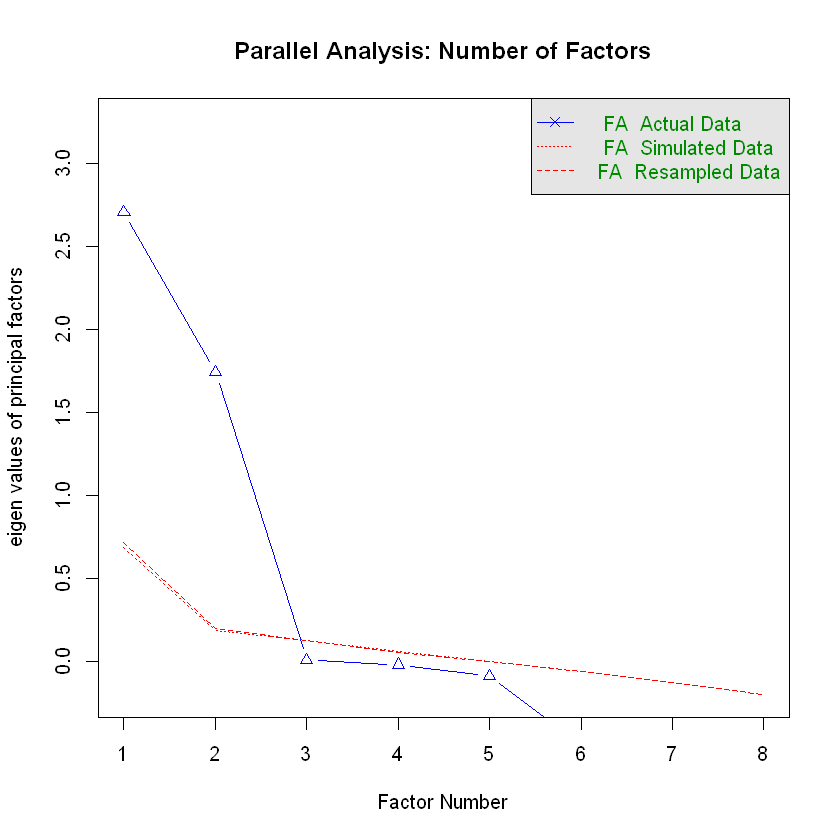

In [4]:
# ── Parallel analysis ─────────────────────────────────────────────────────────
pa <- psych::fa.parallel(
  fa_data,
  fa     = "fa",
  n.iter = 100,
  fm     = "ml",
  main   = "Parallel Analysis: Number of Factors"
)
cat(sprintf("Parallel analysis suggests %d factors\n", pa$nfact))

# ── VSS and MAP criteria ──────────────────────────────────────────────────────
vss_result <- psych::vss(fa_data, n = 6, fm = "ml", plot = FALSE)
cat("\nVSS and MAP complexity criteria:\n")

# Select columns that actually exist in current psych version
print(vss_result$vss.stats[, c("dof", "chisq", "prob", "sqresid", "fit", "RMSEA", "BIC")])

# MAP is a separate vector in current psych versions
cat("\nMAP criterion by number of factors:\n")
print(round(vss_result$map, 4))
cat(sprintf("MAP criterion minimum at %d factors\n", which.min(vss_result$map)))

---

## Fit and Interpret Factor Solution

In [5]:
# Fit 2-factor model with oblique rotation (oblimin)
# fm="ml": maximum likelihood estimation (best for inference and model fit tests)
# fm="pa": principal axis factoring (robust to non-normality)

fa_fit <- psych::fa(
  fa_data,
  nfactors = 2,
  fm       = "ml",
  rotate   = "oblimin",   # oblique rotation; use 'varimax' for orthogonal
  scores   = "regression"
)

print(fa_fit, digits=3, sort=TRUE)

# Key output:
# ML1, ML2: loadings on each factor (> |0.30| considered meaningful)
# h2: communality = variance of variable explained by factors
# u2: uniqueness = 1 - h2 = variance NOT explained by common factors
# com: complexity = how many factors a variable loads on

cat(sprintf("\nModel fit:\n"))
cat(sprintf("  RMSEA: %.3f (< 0.06 = good fit)\n", fa_fit$RMSEA[1]))
cat(sprintf("  TLI:   %.3f (> 0.95 = good fit)\n", fa_fit$TLI))
cat(sprintf("  χ²:    %.1f, df=%d, p=%.3f\n",
            fa_fit$chi, fa_fit$dof, fa_fit$PVAL))

Factor Analysis using method =  ml
Call: psych::fa(r = fa_data, nfactors = 2, rotate = "oblimin", scores = "regression", 
    fm = "ml")
Standardized loadings (pattern matrix) based upon correlation matrix
             item    ML1    ML2    h2    u2  com
nitrate         1  0.891 -0.079 0.783 0.217 1.02
phosphorus      2  0.793 -0.059 0.620 0.380 1.01
ammonia         3  0.776 -0.036 0.596 0.404 1.00
turbidity       4  0.725  0.285 0.660 0.340 1.30
conductivity    5 -0.045  0.838 0.695 0.305 1.01
dissolved_O2    7 -0.035 -0.777 0.612 0.388 1.00
flow_var        6 -0.009  0.753 0.566 0.434 1.00
temperature     8  0.014  0.712 0.510 0.490 1.00

                        ML1   ML2
SS loadings           2.561 2.480
Proportion Var        0.320 0.310
Cumulative Var        0.320 0.630
Proportion Explained  0.508 0.492
Cumulative Proportion 0.508 1.000

 With factor correlations of 
      ML1   ML2
ML1 1.000 0.126
ML2 0.126 1.000

Mean item complexity =  1
Test of the hypothesis that 2 factors are 

---

## Visualising Factor Structure

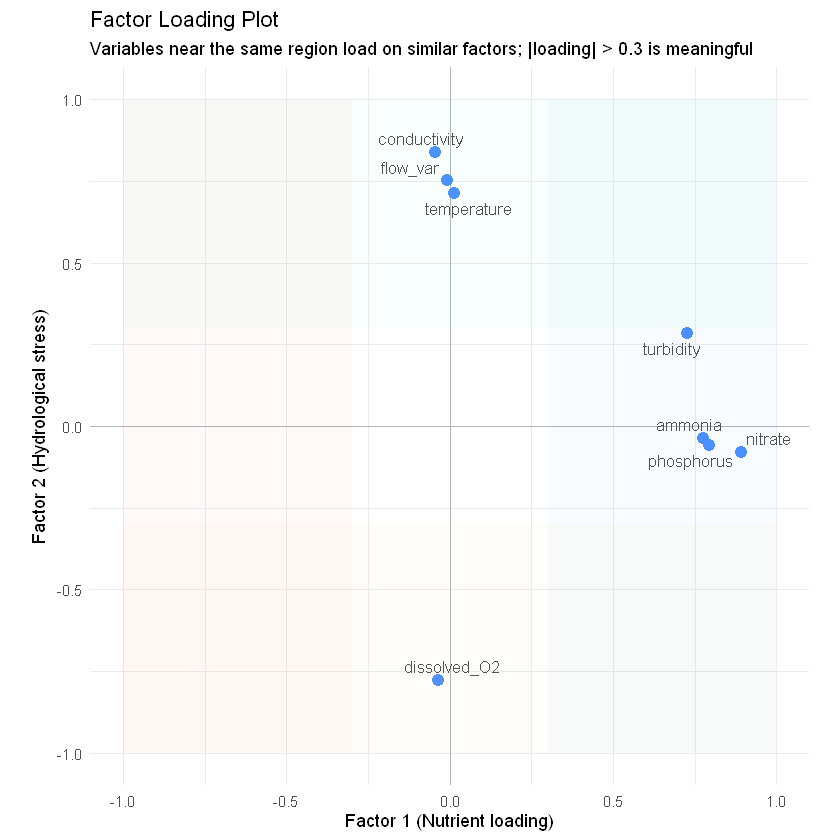

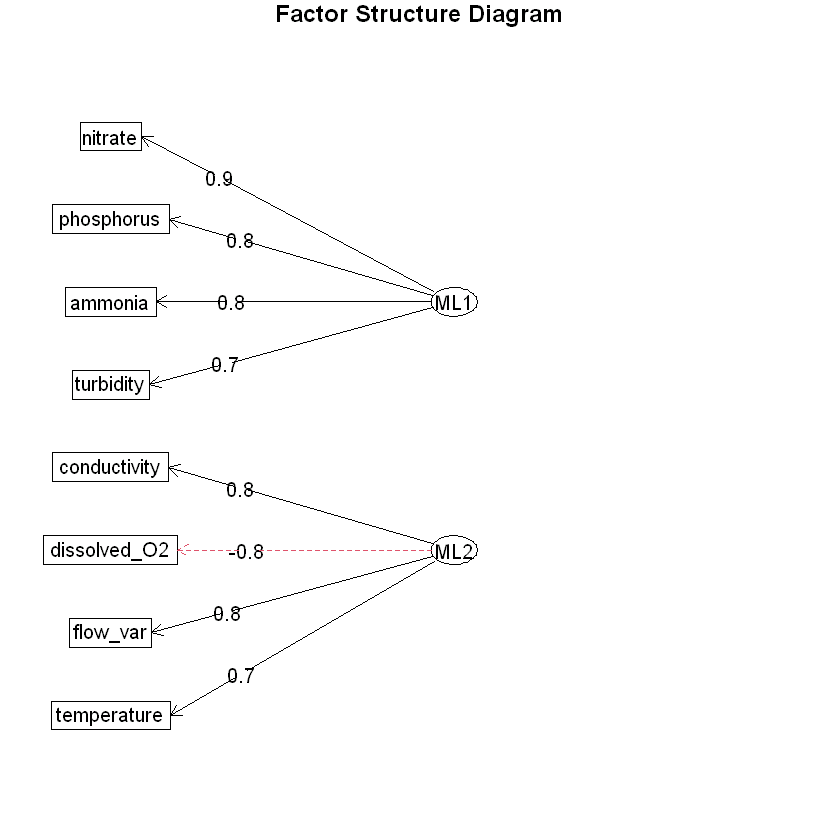

In [6]:
# ── Loading plot ──────────────────────────────────────────────────────────────
loadings_df <- as_tibble(unclass(fa_fit$loadings), rownames="variable") %>%
  rename(Factor1=ML1, Factor2=ML2)

ggplot(loadings_df, aes(x=Factor1, y=Factor2, label=variable)) +
  geom_hline(yintercept=0, color="gray70") +
  geom_vline(xintercept=0, color="gray70") +
  geom_point(color="#4a8fff", size=3) +
  ggrepel::geom_text_repel(size=3.5, color="gray30") +
  annotate("rect", xmin=0.3, xmax=1, ymin=-1, ymax=1,
           alpha=0.04, fill="#4a8fff") +
  annotate("rect", xmin=-1, xmax=-0.3, ymin=-1, ymax=1,
           alpha=0.04, fill="#ff6b6b") +
  annotate("rect", xmin=-1, xmax=1, ymin=0.3, ymax=1,
           alpha=0.04, fill="#4fffb0") +
  annotate("rect", xmin=-1, xmax=1, ymin=-1, ymax=-0.3,
           alpha=0.04, fill="#ffd166") +
  labs(title="Factor Loading Plot",
       subtitle="Variables near the same region load on similar factors; |loading| > 0.3 is meaningful",
       x="Factor 1 (Nutrient loading)", y="Factor 2 (Hydrological stress)") +
  coord_fixed(xlim=c(-1,1), ylim=c(-1,1)) +
  theme_minimal()

# ── Factor diagram ────────────────────────────────────────────────────────────
psych::fa.diagram(fa_fit, main="Factor Structure Diagram",
                  cut=0.30, simple=FALSE)

---

## Common Pitfalls

**1. Using Kaiser's rule (eigenvalue > 1) to choose number of factors**  
Kaiser's rule was developed for PCA of correlation matrices and systematically overestimates the number of factors in EFA. Always use parallel analysis as the primary criterion. The MAP criterion is a reliable secondary check.

**2. Defaulting to orthogonal (varimax) rotation without justification**  
Orthogonal rotation forces factors to be uncorrelated. Most real-world constructs (stress, water quality, ecological health) are correlated. Oblique rotation (oblimin, promax) is more realistic — if the factor correlation turns out to be near zero, the oblique and orthogonal solutions will be nearly identical anyway.

**3. Interpreting cross-loadings as confirming multiple factor membership**  
A variable with loadings of 0.45 on Factor 1 and 0.40 on Factor 2 does not "belong to both factors" — it has a complex structure that reduces the interpretability of both. Items with high complexity (com > 2) should be dropped in scale development.

**4. Confusing communality with reliability**  
Communality (h²) measures the proportion of a variable's variance explained by the common factors. It is not a measure of measurement reliability (which requires test-retest or internal consistency data). Low communality means the factor model explains little of that variable's variance — consider dropping it or adding factors.

**5. Reporting EFA and CFA on the same dataset**  
EFA explores factor structure; CFA confirms it. Running EFA to find a structure, then CFA to "confirm" it on the same data is circular and will produce inflated fit statistics. CFA must be conducted on a new, independent sample.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*